## readme

Die Lösung geliedert sich in 4 Teile. Sie sind
- Task 1
- Task 2
- Task 3
- Task 4

der Code und desen Ergebnis / Visualisierung ist schon erzeugt.

Man bracht nur klicken, dann sieht man das Ergebnis reibungslos.

In [60]:
import numpy as np
import matplotlib.pyplot as plt

## load data

In [68]:
# die Bilder dere Trainingsdaten und die zugehörigen Labels laden
imgs = np.fromfile("train-images-idx3-ubyte", dtype=np.uint8)
imgs = np.reshape(imgs[16:], [-1, 28, 28])

labs = np.fromfile("train-labels-idx1-ubyte", dtype=np.uint8)
labs = labs[8:]
# imgs.shape:  (60000, 28, 28)
# labs.shape:  (60000,)

# test daten und labels laden
imgs_test = np.fromfile("t10k-images-idx3-ubyte", dtype=np.uint8)
imgs_test = np.reshape(imgs_test[16:], [-1, 28, 28])

labs_test = np.fromfile("t10k-labels-idx1-ubyte", dtype=np.uint8)
labs_test = labs_test[8:]


## task 1

In [80]:
# for task 1 and 2
def pixelwise_mean(images):
    """
    images: shape (N, 28, 28)
    return: mean image of shape (28, 28)

    b = (1/N) * Σ(xn), n from 0 to N-1

    axis = 0 means: 
    for i in range(28):
        for j in range(28):
            mean[i, j] = average over n of images[n, i, j]

    for n in range(N):
        s += images[n, i, j]


    def pixelwise_mean_loop(images):
    # this code is equvilent to pixelwise_mean()
        N, H, W = images.shape
        mean_img = np.zeros((H, W))

        for i in range(H):
            for j in range(W):
                s = 0.0
                for n in range(N):
                    s += images[n, i, j]
                mean_img[i, j] = s / N

        return mean_img

    """
    return np.mean(images, axis=0)

def pixelwise_variance(images):
    """
    images: shape (N, 28, 28)
    return: variance image of shape (28, 28)
    V = (1/N) * Σ(x_n - b)^2, n from 0 to N-1
    """    
    mean_img = pixelwise_mean(images)
    return np.mean((images - mean_img) ** 2, axis=0)

def task1():
    mean_images = []
    var_images = []

    for digit in range(10):
        indices = np.where(labs == digit)[0]
        imgs_d = imgs[indices[:100]]

        mean_images.append(pixelwise_mean(imgs_d))
        var_images.append(pixelwise_variance(imgs_d))
        
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))

    for d, ax in enumerate(axes.flat):
        ax.imshow(mean_images[d], cmap="gray")
        ax.set_title(f"Mean digit {d}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    

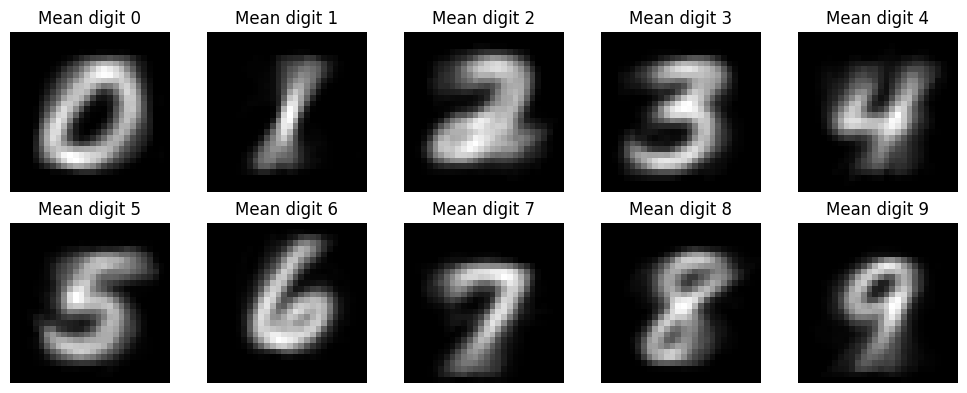

In [81]:
task1()

## task 2

In [ ]:
def task2():
    imgs_1000 = imgs[:1000]              # (1000, 28, 28)
    X = imgs_1000.reshape(1000, -1)      # (1000, 784)
    X = X.T                              # (784, 1000), colum is sample

    # calculate mean and decentralize
    b = np.mean(X, axis=1, keepdims=True)   # (784, 1)
    Y = X - b                               # (784, 1000)

    # create covariance matrix, using the formular given in task description
    S = Y @ Y.T    # (784, 784)

    # calculate eigenvalues
    eigvals = np.linalg.eigvalsh(S)   # because symmetric matrix，use eigvalsh
    eigvals = np.sort(eigvals)[::-1]  #  sort it descending

    # calculate singular values
    singvals = np.linalg.svd(Y, compute_uv=False)
    singvals_sq = singvals**2

    # plot the result
    plt.figure(figsize=(5,3))
    plt.plot(eigvals[:50], label="Eigenvalues of S")
    plt.plot(singvals_sq[:50], "--", label="Squared singular values of Y")
    plt.legend()
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title("Eigenvalues vs squared singular values")
    plt.grid(True)
    plt.show()


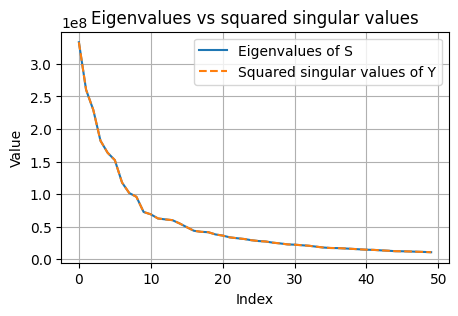

In [71]:
task2()

## task 3

In [75]:
# for task 3
def as_column_vectors(imgs_subset):
    # imgs_subset: (N, 28, 28)
    X = imgs_subset.reshape(imgs_subset.shape[0], -1).T  # (784, N)
    return X

def best_affine_subspace_pca(X, d):
    """
    X: (D, N) columns are samples
    d: target dimension
    returns:
      A: (D, d) orthonormal columns
      b: (D, 1) mean column vector
    """
    b = np.mean(X, axis=1, keepdims=True)   # (D,1)
    Y = X - b                               # (D,N)

    # SVD: Y = U Σ V^T
    U, S, VT = np.linalg.svd(Y, full_matrices=False)
    A = U[:, :d]                            # (D,d)
    return A, b

def show_image(vec, title, ax, cmap="gray"):
    ax.imshow(vec.reshape(28, 28), cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

def project_to_subspace(x, A, b):
    """
    x: (D,) or (D,1)
    A: (D,d)
    b: (D,1)
    returns projected x_hat: (D,1)
    """
    x = x.reshape(-1, 1)
    return A @ (A.T @ (x - b)) + b

def task3_mean_hauptkomponent_first_1000():
    # compute
    X_train = as_column_vectors(imgs[:1000])
    A, b = best_affine_subspace_pca(X_train, d=5)

    fig, axes = plt.subplots(1, 6, figsize=(13, 3))
    show_image(b[:, 0], "mean b", axes[0])

    for i in range(5):
        show_image(A[:, i], f"PC {i+1}", axes[i+1])

    plt.tight_layout()
    plt.show()

def task3_projizieren():
    # pick 4 test images (any four)
    test_ids = [0, 1, 2, 3]

    fig, axes = plt.subplots(len(test_ids), 2, figsize=(5, 4))

    for r, idx in enumerate(test_ids):
        x = imgs_test[idx].reshape(-1, 1)       # (784,1)
        x_hat = project_to_subspace(x, A, b)    # (784,1)

        show_image(x[:, 0], f"test {idx} (label {labs_test[idx]})", axes[r, 0])
        show_image(x_hat[:, 0], "projection", axes[r, 1])

    plt.tight_layout()
    plt.show()


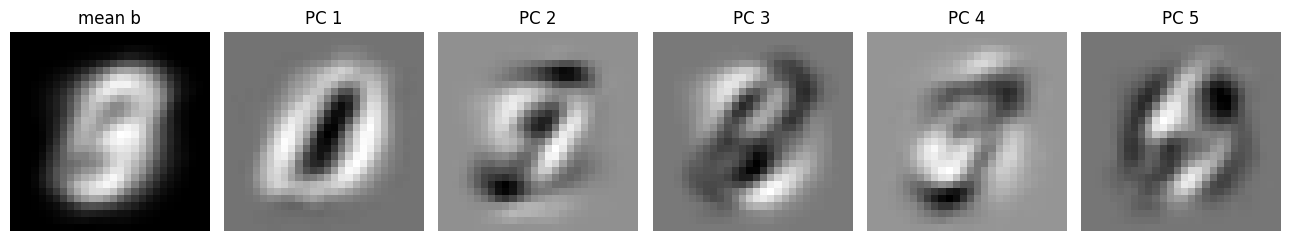

In [76]:
task3_mean_hauptkomponent_first_1000()

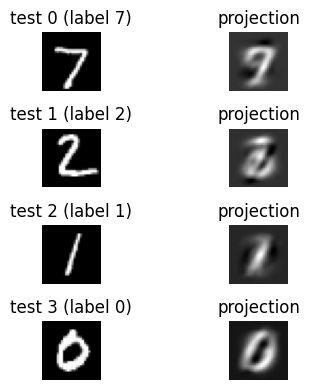

In [77]:
task3_projizieren()

## task 4

In [78]:

# for task 4
def to_col_vectors(imgs_subset):
    # (N,28,28) -> (784,N)
    return imgs_subset.reshape(imgs_subset.shape[0], -1).T.astype(np.float64)

def pca_fit(X, d=5):
    # X: (D,N)
    b = np.mean(X, axis=1, keepdims=True)     # (D,1)
    Y = X - b                                  # (D,N)
    U, S, VT = np.linalg.svd(Y, full_matrices=False)
    A = U[:, :d]                               # (D,d)
    return A, b

def pca_transform(X, A, b):
    # return Z: (d,N) = A^T (X - b)
    return A.T @ (X - b)

def kmeans_2d(Z, r0, r1, max_iter=100, tol=1e-6):
    """
    Z: (2,N) data
    r0, r1: (2,) initial centers
    returns: centers (2,2) and labels (N,) in {0,1}
    """
    centers = np.stack([r0, r1], axis=0)  # (2,2)
    N = Z.shape[1]

    for _ in range(max_iter):
        # distances to centers
        # dists[k, n] = ||z_n - center_k||^2
        d0 = np.sum((Z.T - centers[0])**2, axis=1)
        d1 = np.sum((Z.T - centers[1])**2, axis=1)
        labels = (d1 < d0).astype(int)  # 0 if closer to c0 else 1

        new_centers = centers.copy()
        for k in [0, 1]:
            idx = np.where(labels == k)[0]
            if len(idx) > 0:
                new_centers[k] = np.mean(Z[:, idx].T, axis=0)

        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol:
            break

    return centers, labels

def first_n_of_digit(imgs, labs, digit, n):
    idx = np.where(labs == digit)[0][:n]
    return imgs[idx], labs[idx]

def task4():
    # Task 4
    digitA, digitB = 5, 8

    # 1) build training dataset: choose 500 + 500 = 1000 (simple & balanced)
    imgsA_tr, _ = first_n_of_digit(imgs, labs, digitA, 500)
    imgsB_tr, _ = first_n_of_digit(imgs, labs, digitB, 500)

    imgs_tr = np.concatenate([imgsA_tr, imgsB_tr], axis=0)
    labs_tr = np.array([digitA]*len(imgsA_tr) + [digitB]*len(imgsB_tr))

    X_tr = to_col_vectors(imgs_tr)  # (784,1000)

    # 2) PCA on this dataset, project to 2D
    A2, b2 = pca_fit(X_tr, d=2)
    Z_tr = pca_transform(X_tr, A2, b2)  # (2,1000)

    # 3) init centers as mean of projected two digits
    Z_A = Z_tr[:, labs_tr == digitA]
    Z_B = Z_tr[:, labs_tr == digitB]
    rA0 = np.mean(Z_A, axis=1)  # (2,)
    rB0 = np.mean(Z_B, axis=1)  # (2,)

    centers, labels = kmeans_2d(Z_tr, rA0, rB0)

    # Map cluster -> digit using which init mean is closer
    # If center0 is closer to rA0, then cluster0 -> digitA else digitB
    if np.linalg.norm(centers[0] - rA0) + np.linalg.norm(centers[1] - rB0) <= \
    np.linalg.norm(centers[0] - rB0) + np.linalg.norm(centers[1] - rA0):
        cluster_to_digit = {0: digitA, 1: digitB}
    else:
        cluster_to_digit = {0: digitB, 1: digitA}

    pred_digits_tr = np.vectorize(cluster_to_digit.get)(labels)

    # 4) scatter plot
    plt.figure(figsize=(4,3))
    plt.scatter(Z_tr[0], Z_tr[1], c=labels, s=8)
    plt.scatter(centers[:,0], centers[:,1], s=120, marker="x")
    plt.title(f"K-Means on PCA(2D): digits {digitA} vs {digitB}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    # 5) test classification: 100 test images for each digit
    imgsA_te, _ = first_n_of_digit(imgs_test, labs_test, digitA, 100)
    imgsB_te, _ = first_n_of_digit(imgs_test, labs_test, digitB, 100)

    imgs_te = np.concatenate([imgsA_te, imgsB_te], axis=0)
    true_te = np.array([digitA]*len(imgsA_te) + [digitB]*len(imgsB_te))

    X_te = to_col_vectors(imgs_te)                # (784,200)
    Z_te = pca_transform(X_te, A2, b2)            # (2,200)

    # classify by nearest final center
    d0 = np.sum((Z_te.T - centers[0])**2, axis=1)
    d1 = np.sum((Z_te.T - centers[1])**2, axis=1)
    labels_te = (d1 < d0).astype(int)
    pred_te = np.vectorize(cluster_to_digit.get)(labels_te)

    # table counts
    def count_correct_for_digit(d):
        mask = (true_te == d)
        correct = np.sum(pred_te[mask] == true_te[mask])
        wrong = np.sum(pred_te[mask] != true_te[mask])
        return correct, wrong

    cA, wA = count_correct_for_digit(digitA)
    cB, wB = count_correct_for_digit(digitB)

    print("Results (100 test images each):")
    print(f"Digit {digitA}: correct={cA}, wrong={wA}")
    print(f"Digit {digitB}: correct={cB}, wrong={wB}")


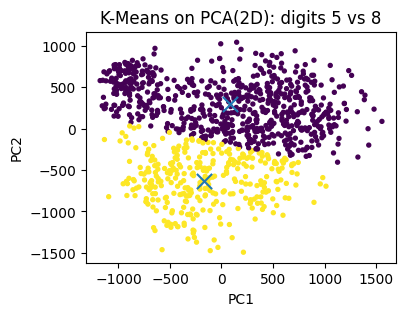

Results (100 test images each):
Digit 5: correct=95, wrong=5
Digit 8: correct=42, wrong=58


In [79]:
task4()